In [391]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [392]:
df = pd.read_csv("retail_store_sales.csv")

In [393]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [394]:
df.shape

(12575, 11)

In [395]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [396]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


**Missing Values**

In [397]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

**duplicate rows**

In [398]:
df.duplicated().sum()

np.int64(0)

In [399]:
df.dtypes

Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied     object
dtype: object

**Unique Values**

In [400]:
for col in df.columns:
    print("="*60)
    print(col)
    print(df[col].unique())

Transaction ID
<StringArray>
['TXN_6867343', 'TXN_3731986', 'TXN_9303719', 'TXN_9458126', 'TXN_4575373',
 'TXN_7482416', 'TXN_3652209', 'TXN_1372952', 'TXN_9728486', 'TXN_2722661',
 ...
 'TXN_1712895', 'TXN_6298574', 'TXN_4890318', 'TXN_1096134', 'TXN_2318174',
 'TXN_9347481', 'TXN_4009414', 'TXN_5306010', 'TXN_5167298', 'TXN_2407494']
Length: 12575, dtype: str
Customer ID
<StringArray>
['CUST_09', 'CUST_22', 'CUST_02', 'CUST_06', 'CUST_05', 'CUST_07', 'CUST_21',
 'CUST_23', 'CUST_25', 'CUST_14', 'CUST_15', 'CUST_17', 'CUST_01', 'CUST_10',
 'CUST_04', 'CUST_13', 'CUST_18', 'CUST_08', 'CUST_20', 'CUST_12', 'CUST_11',
 'CUST_19', 'CUST_16', 'CUST_24', 'CUST_03']
Length: 25, dtype: str
Category
<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and 

In [401]:
df.nunique()

Transaction ID      12575
Customer ID            25
Category                8
Item                  200
Price Per Unit         25
Quantity               10
Total Spent           227
Payment Method          3
Location                2
Transaction Date     1114
Discount Applied        2
dtype: int64

***DATA CLEANING***

In [402]:
df_clean = df.copy()

**Convert Data Types**

In [403]:
numeric_cols=[
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

for col in numeric_cols:
    df_clean[col]=pd.to_numeric(df_clean[col],errors="coerce")

In [404]:
# date column
df_clean["Transaction Date"]=pd.to_datetime(
    df_clean["Transaction Date"],
    errors="coerce"
)

**Fill Missing Values (Categorical)**

In [405]:
# item
df_clean["Item"] = df_clean["Item"].fillna(
    df_clean["Item"].mode()[0]
)

In [406]:
# discount
df_clean["Discount Applied"] = df_clean["Discount Applied"].fillna(
    df_clean["Discount Applied"].mode()[0]
)

**Fill Missing Numerical Value**

In [407]:
# quantity
df_clean["Quantity"]=df_clean["Quantity"].fillna(
    df_clean["Quantity"].median(),
   
)

In [408]:
#Price Per Unit
df_clean["Price Per Unit"]=df_clean["Price Per Unit"].fillna(
    df_clean["Price Per Unit"].median(),
  
)

In [409]:
# total spent
df_clean["Total Spent"]=(
    df_clean["Quantity"]*
    df_clean["Price Per Unit"]
)

**Check Negative Values**

In [410]:
df_clean[df_clean["Quantity"]<=0]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [411]:
df_clean[df_clean["Price Per Unit"]<=0]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [412]:
df_clean[df_clean["Total Spent"]<=0]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [413]:
df_clean=df_clean[df_clean["Quantity"]>0]

df_clean=df_clean[df_clean["Price Per Unit"]>0]

df_clean=df_clean[df_clean["Total Spent"]>0]

**Check Outliers**

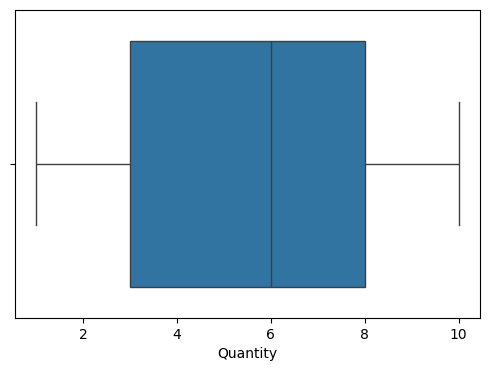

In [414]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean["Quantity"])
plt.show()

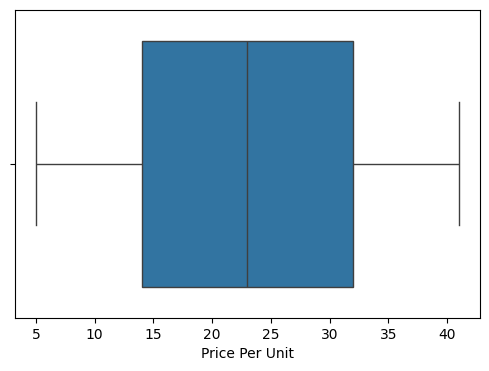

In [415]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean["Price Per Unit"])
plt.show()

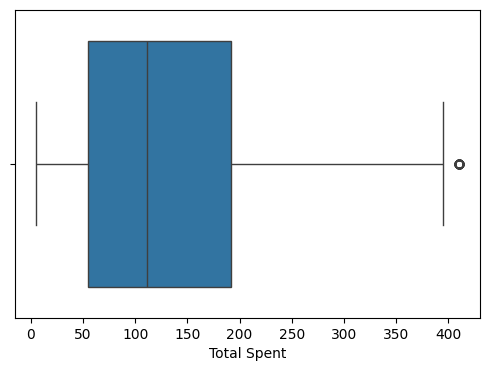

In [416]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean["Total Spent"])
plt.show()

**Remove Outliers (IQR and clip method)**

In [417]:
print(df_clean.shape)

(12575, 11)


In [418]:
Q1 = df_clean["Total Spent"].quantile(0.25)
Q3 = df_clean["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean["Total Spent"] = df_clean["Total Spent"].clip(lower, upper)

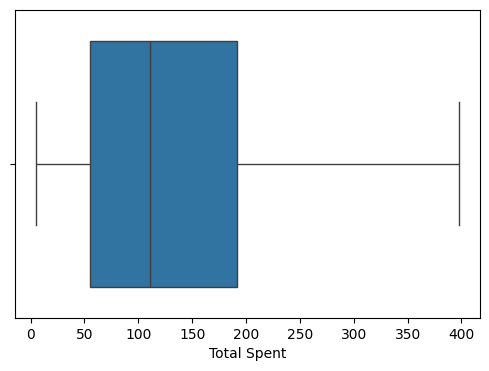

In [419]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean["Total Spent"])
plt.show()

**Standardize Text**

In [420]:
text_cols = ["Category", "Item", "Payment Method", "Location"]

for col in text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

**Feature Engineering**

In [421]:
df_clean["Year"]=df_clean["Transaction Date"].dt.year

In [422]:
df_clean["Month"]=df_clean["Transaction Date"].dt.month_name()

In [423]:
df_clean["Quarter"]=df_clean["Transaction Date"].dt.quarter

In [424]:
df_clean["Day"]=df_clean["Transaction Date"].dt.day_name()

In [425]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  str           
 1   Customer ID       12575 non-null  str           
 2   Category          12575 non-null  str           
 3   Item              12575 non-null  str           
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  str           
 8   Location          12575 non-null  str           
 9   Transaction Date  12575 non-null  datetime64[us]
 10  Discount Applied  12575 non-null  object        
 11  Year              12575 non-null  int32         
 12  Month             12575 non-null  str           
 13  Quarter           12575 non-null  int32         
 14  Day               12575 non-null 

In [426]:
df_clean.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Year                0
Month               0
Quarter             0
Day                 0
dtype: int64

**Exploratory Data Analysis**

**Graph 1: Monthly Sales Trend**

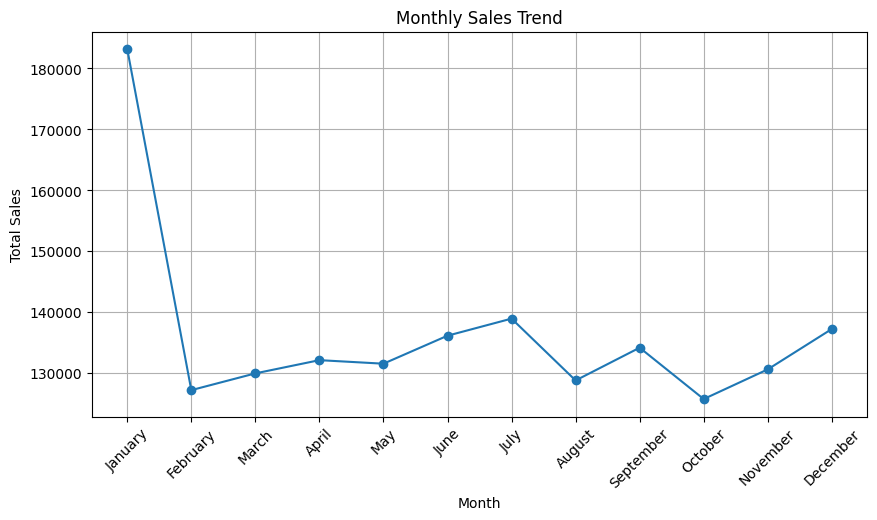

In [428]:
monthly_sales = df_clean.groupby("Month")["Total Spent"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Graph 2: Top 10 Selling Products**

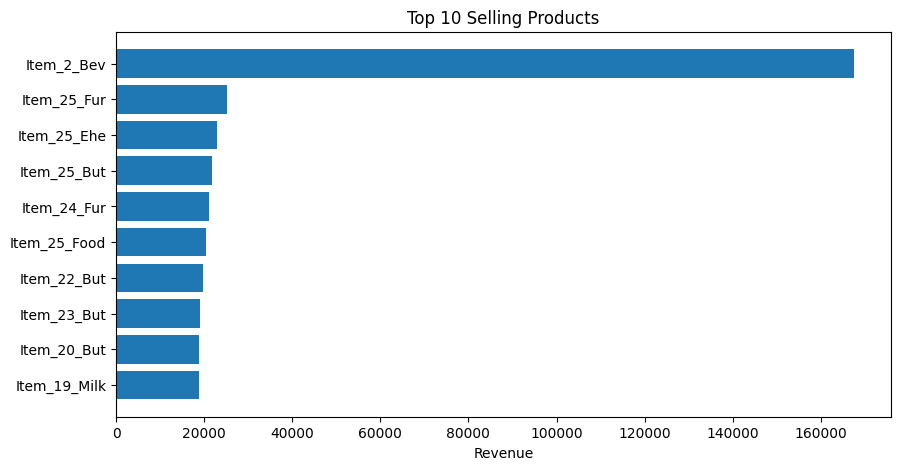

In [429]:
top_products = (
    df_clean.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Selling Products")
plt.xlabel("Revenue")
plt.gca().invert_yaxis()
plt.show()

**Graph 3: Sales by Category**

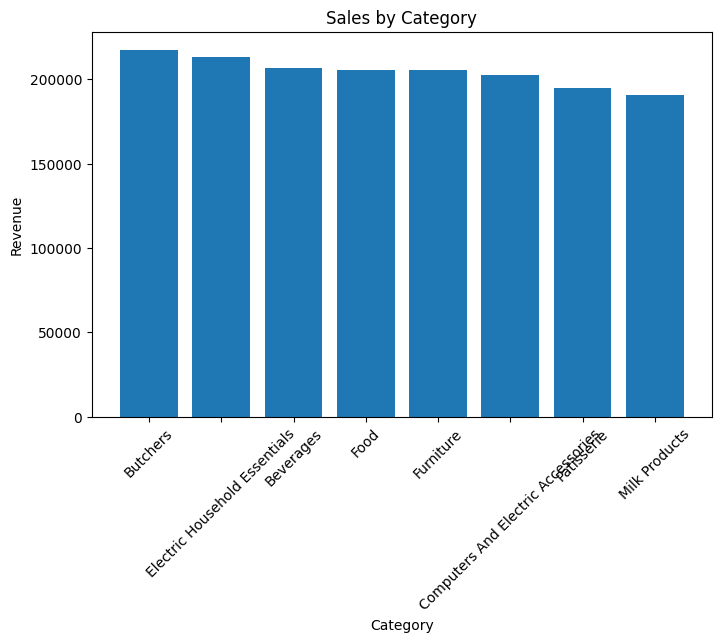

In [432]:
category_sales = (
    df_clean.groupby("Category")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**Graph 4: Payment Method Distribution**

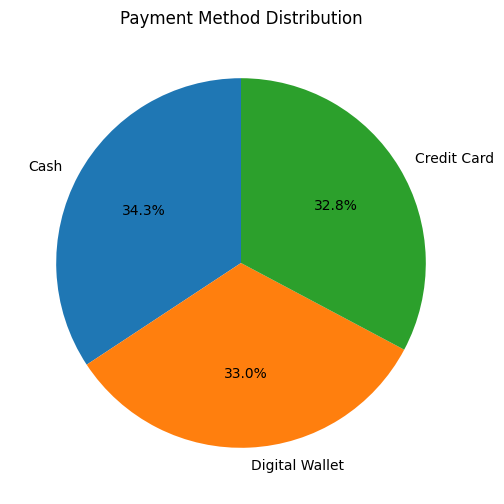

In [433]:
payment = df_clean["Payment Method"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    payment.values,
    labels=payment.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Payment Method Distribution")
plt.show()

**Graph 5: Sales by Location**

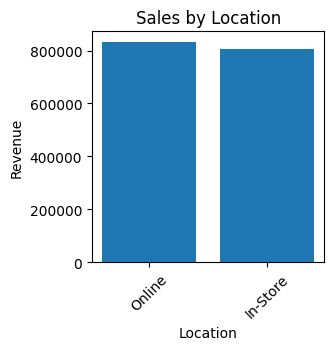

In [437]:
location_sales = (
    df_clean.groupby("Location")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(3,3))
plt.bar(location_sales.index, location_sales.values)
plt.title("Sales by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**Graph 6: Correlation Heatmap**

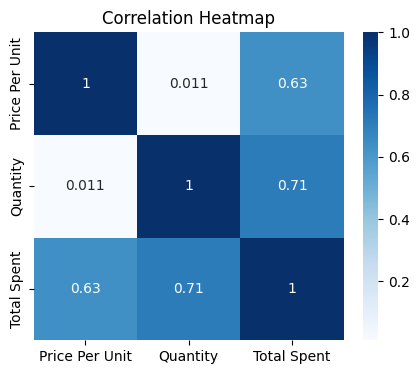

In [438]:
corr = df_clean[
    ["Price Per Unit","Quantity","Total Spent"]
].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

**Graph 7: Quantity Distribution**

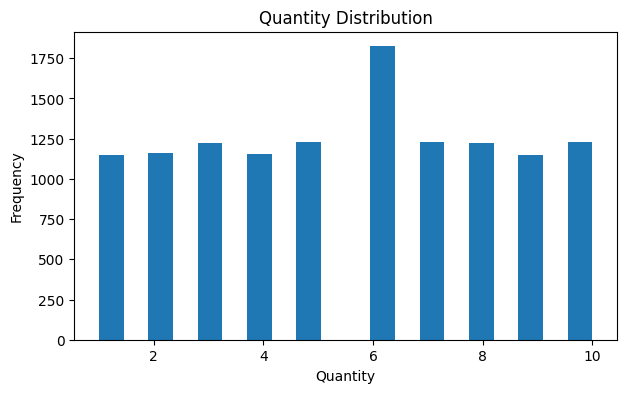

In [439]:
plt.figure(figsize=(7,4))
plt.hist(df_clean["Quantity"], bins=20)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

**Graph 8: Revenue Distribution (Boxplot)**

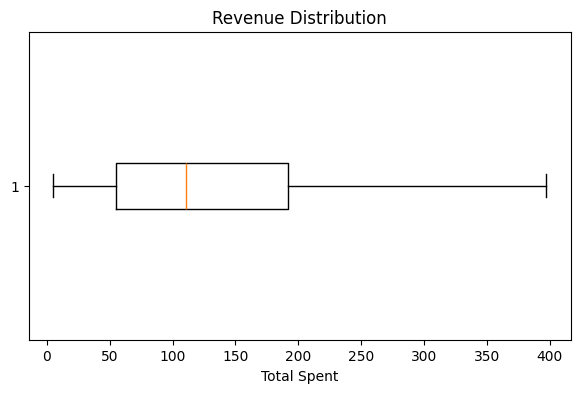

In [440]:
plt.figure(figsize=(7,4))
plt.boxplot(df_clean["Total Spent"], vert=False)
plt.title("Revenue Distribution")
plt.xlabel("Total Spent")
plt.show()

In [441]:
df_clean.to_csv("cleaned_retail_sales.csv", index=False)